# 450 · 통합 리포트 — 3일간의 성적표

 **CPU로 실행 가능**

앞선 노트북들이 `artifacts/`에 남긴 결과를 읽어 최종 비교표와 리포트를 만든다.
**새로 모델을 돌리지 않는다** — 이 노트북은 집계만 한다.

## 산출물
```
artifacts/report/<run_id>/comparison.csv
artifacts/report/<run_id>/final_report.md
artifacts/report/<run_id>/comparison.png
```


In [1]:
# --- 패키지 설치 (Colab) ---
# 설치 후 "런타임 다시 시작" 안내가 나오면 재시작하고, 다음 셀부터 이어서 실행한다.
!pip install -q transformers==4.57.1 datasets==4.0.0 accelerate==1.10.1 \
    peft==0.17.1 trl==0.23.0 bitsandbytes==0.47.0 tiktoken==0.11.0
!apt-get install -y fonts-nanum -qq > /dev/null   # matplotlib 한글 폰트

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.7/564.7 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
# --- 저장소 클론 및 루트 이동 (Colab) ---
from pathlib import Path

if not Path("common/config.py").exists():
    !git clone -q https://github.com/ironmanciti/LLM_FineTuning_Lecture.git
    %cd LLM_FineTuning_Lecture
print("저장소 루트:", Path.cwd())

from common import config as C, env, artifacts as art
env.set_seed(C.SEED)

/content/LLM_FineTuning_Lecture
저장소 루트: /content/LLM_FineTuning_Lecture


42

In [3]:
# --- Google Drive 연결: artifacts/ 영속화 (Colab) ---
# 노트북마다 런타임(VM)이 다르므로, 산출물을 Drive에 두어야 다음 노트북에서 읽을 수 있다.
import shutil
from pathlib import Path

try:
    from google.colab import drive  # Colab이 아니면 ImportError

    drive.mount("/content/drive")

    DRIVE_ART = Path("/content/drive/MyDrive/LLM_FineTuning_Lecture/artifacts")
    DRIVE_ART.mkdir(parents=True, exist_ok=True)

    local_art = Path("artifacts")
    if not local_art.is_symlink():
        if local_art.exists():  # 이미 로컬에 쓴 결과가 있으면 Drive로 이관
            shutil.copytree(local_art, DRIVE_ART, dirs_exist_ok=True)
            shutil.rmtree(local_art)
        local_art.symlink_to(DRIVE_ART)
    print("artifacts ->", local_art.resolve())
except ImportError:
    print("Colab이 아니므로 로컬 artifacts/ 를 그대로 사용합니다.")


Mounted at /content/drive
artifacts -> /content/drive/MyDrive/LLM_FineTuning_Lecture/artifacts


In [4]:
import json
import pandas as pd
from common import metrics as M

RUN_ID = art.latest_run()
assert RUN_ID, "artifacts/runs/ 가 비어 있습니다."
rd = art.report_dir(RUN_ID)      # 그림 셀보다 먼저 만든다 (그림이 실패해도 리포트는 나와야 한다)
print("run_id:", RUN_ID)
print("리포트 경로:", rd)

# 있는 것만 모은다. 없는 단계는 표에서 '-'로 표시한다.
sources = {
    "token_cost": art.load_json(art.token_cost_path(), default=None),
    "anatomy": art.load_json(art.ART / "anatomy.json", default=None),
    "data_report": art.load_json(art.data_path("data_report.json"), default=None),
    "run_cfg": art.load_json(art.run_dir(RUN_ID) / "config.json", default=None),
    "history": art.load_json(art.run_dir(RUN_ID) / "history.json", default=None),
    "eval": art.load_json(art.eval_dir(RUN_ID) / "summary.json", default=None),
    "merged": art.load_json(art.eval_dir(RUN_ID, "merged") / "metrics.json", default=None),
    "merged_card": (art.merged_dir(RUN_ID) / "model_card.md"),
    "rubric": art.load_json(art.eval_dir(RUN_ID) / "rubric.json", default=None),
    "regression": art.load_json(art.eval_dir(RUN_ID) / "regression.json", default=None),
}
for k, v in sources.items():
    ok = (v.exists() if hasattr(v, "exists") else v is not None)
    print(f"  {'[OK]  ' if ok else '[없음]'} {k}")

run_id: r16a32_all-linear_lr0.0002_ep2_len768
리포트 경로: /content/LLM_FineTuning_Lecture/artifacts/report/r16a32_all-linear_lr0.0002_ep2_len768
  [없음] token_cost
  [없음] anatomy
  [OK]   data_report
  [OK]   run_cfg
  [OK]   history
  [OK]   eval
  [OK]   merged
  [OK]   merged_card
  [없음] rubric
  [OK]   regression


---
## 1. 성적표 — 4방식 비교 (§3.14-1)

행: 조건 / 열: 정확성 · 형식 · 지연 · 자원 · 제약
`few-shot` 조건은 선택 과제다(아래 셀에서 자동 채움 여부 판단).

In [5]:
ev = sources["eval"]; mg = sources["merged"]; cfg = sources["run_cfg"]
assert ev, "430을 먼저 실행하십시오."

def row(name, m, note=""):
    f = m["format"]
    return {
        "조건": name,
        "EM": m["em"], "문자F1": m["f1"],
        "JSON(엄격)%": f["strict_json_pct"], "JSON(관대)%": f["lenient_json_pct"],
        "필수필드%": f["required_fields_pct"], "정상종료%": f["clean_stop_pct"],
        "건당지연(초)": m.get("latency_per_item") or m.get("latency_sec_per_item"),
        "비고": note,
    }

rows = [
    row("① 베이스 (프롬프트만)", ev["conditions"]["base"], "학습 없음. 기준선"),
    row("② QLoRA SFT (4bit+어댑터)", ev["conditions"]["tuned"],
        f"어댑터 {cfg['lora']['trainable_pct']}% 학습" if cfg else ""),
]
if mg:
    rows.append(row("③ 병합본 (16bit)", mg, "4bit 학습 -> 16bit 병합"))

comp = pd.DataFrame(rows)
display(comp)

,조건,EM,문자F1,JSON(엄격)%,JSON(관대)%,필수필드%,정상종료%,건당지연(초),비고
0,① 베이스 (프롬프트만),7.5,23.07,6.5,7.0,4.5,100.0,5.215,학습 없음. 기준선
1,② QLoRA SFT (4bit+어댑터),60.5,71.75,97.5,97.5,97.5,100.0,9.989,어댑터 2.7162% 학습
2,③ 병합본 (16bit),60.0,71.78,97.0,97.0,97.0,100.0,3.601,4bit 학습 -> 16bit 병합


In [6]:
# 자원·제약 열 — 형제 과정의 의사결정 표와 이어지는 축
res_rows = []
if cfg:
    res_rows.append({"조건": "② QLoRA SFT", "학습 시간(분)": cfg["result"]["elapsed_min"],
                     "피크 VRAM(GB)": cfg["result"]["peak_vram_gb"],
                     "산출물 크기": "어댑터 수십 MB", "데이터 반출": "없음 (로컬 학습)"})
    res_rows.append({"조건": "① 베이스", "학습 시간(분)": 0,
                     "피크 VRAM(GB)": cfg["result"]["base_load_vram_gb"],
                     "산출물 크기": "-", "데이터 반출": "없음"})
if mg:
    res_rows.append({"조건": "③ 병합본", "학습 시간(분)": "-",
                     "피크 VRAM(GB)": "-", "산출물 크기": "베이스 전체 (수 GB)",
                     "데이터 반출": "없음"})
res_rows.append({"조건": "(참고) 상용 API", "학습 시간(분)": 0, "피크 VRAM(GB)": 0,
                 "산출물 크기": "-", "데이터 반출": "★ 있음 — 사내 규정 확인 필요"})
display(pd.DataFrame(res_rows))
print("데이터 반출 제약이 파인튜닝을 선택하는 가장 흔한 실무 이유다 (2일차 §3.7-2).")

,조건,학습 시간(분),피크 VRAM(GB),산출물 크기,데이터 반출
0,② QLoRA SFT,78.41,2.4,어댑터 수십 MB,없음 (로컬 학습)
1,① 베이스,0,0.426,-,없음
2,③ 병합본,-,-,베이스 전체 (수 GB),없음
3,(참고) 상용 API,0,0,-,★ 있음 — 사내 규정 확인 필요


데이터 반출 제약이 파인튜닝을 선택하는 가장 흔한 실무 이유다 (2일차 §3.7-2).


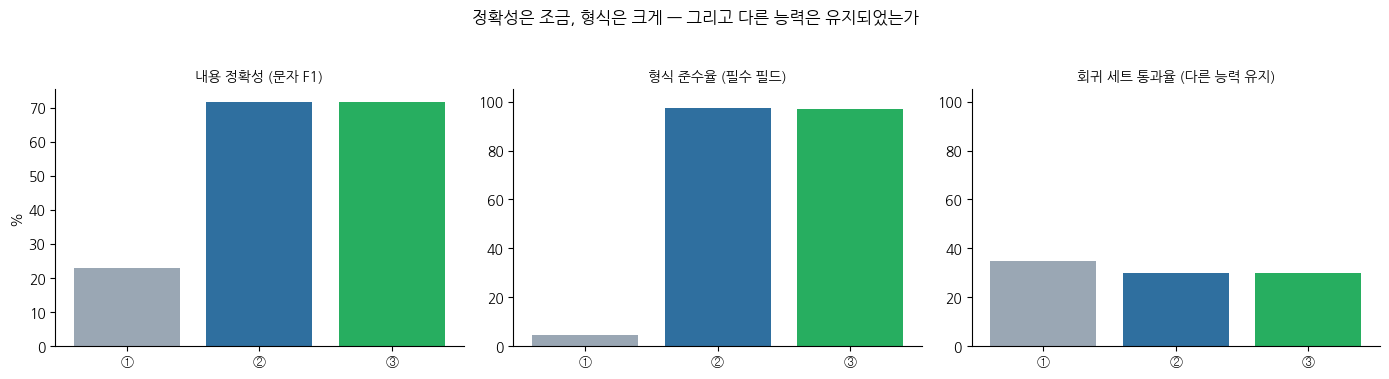

In [7]:
try:
    import matplotlib.pyplot as plt, matplotlib
    matplotlib.font_manager.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    matplotlib.rcParams["font.family"] = "NanumGothic"
    matplotlib.rcParams["axes.unicode_minus"] = False

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
    labels = [r["조건"].split(" ")[0] for r in rows]
    colors = ["#9aa7b4", "#2f6f9f", "#27ae60"][:len(rows)]

    axes[0].bar(labels, [r["문자F1"] for r in rows], color=colors)
    axes[0].set_title("내용 정확성 (문자 F1)", fontsize=10); axes[0].set_ylabel("%")

    axes[1].bar(labels, [r["필수필드%"] for r in rows], color=colors)
    axes[1].set_title("형식 준수율 (필수 필드)", fontsize=10); axes[1].set_ylim(0, 105)

    if sources["regression"]:
        reg = sources["regression"]
        rg = [reg["base"]["pass_pct"], reg["tuned"]["pass_pct"]]
        rl = ["①", "②"]
        mr = art.load_json(art.eval_dir(RUN_ID, "merged") / "regression.json", default=None)
        if mr:
            rg.append(mr["pass_pct"]); rl.append("③")
        axes[2].bar(rl, rg, color=colors[:len(rg)])
        axes[2].set_title("회귀 세트 통과율 (다른 능력 유지)", fontsize=10); axes[2].set_ylim(0, 105)
    else:
        axes[2].text(0.5, 0.5, "회귀 결과 없음", ha="center", va="center")
        axes[2].set_axis_off()

    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle("정확성은 조금, 형식은 크게 — 그리고 다른 능력은 유지되었는가", y=1.04)
    plt.tight_layout()
    plt.savefig(rd / "comparison.png", dpi=140, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"[그림 실패] {type(e).__name__}: {e}")
    print("  리포트 생성은 계속 진행됩니다. 첫 설치 셀(fonts-nanum 포함)을 실행했는지 확인하십시오.")

---
## 2. 의사결정 플로우 (§3.14-2)

**"무조건 파인튜닝"이 답이 아닌 경우**를 자기 데이터로 확인한 결과에 근거해 채운다.

In [8]:
DECISION = {
    "데이터를 외부로 보낼 수 있는가": "아니오 -> 오픈웨이트 로컬. 예 -> API도 후보",
    "라벨(지시-응답)이 몇 건 있는가": "수백 건 미만 -> 프롬프트/few-shot. 수천 건 -> SFT 검토",
    "필요한 것이 형식인가 지식인가": "형식/톤 -> SFT. 지식 -> ★ RAG (SFT로는 안 된다)",
    "지연·VRAM 예산은": "T4 16GB -> 0.5~1.5B QLoRA. 그 이상은 상위 GPU 필요",
    "평가셋이 있는가": "없다 -> 먼저 만든다. 없으면 개선을 증명할 수 없다",
}
for q, a in DECISION.items():
    print(f"  {q}\n    -> {a}")

print("\n" + "=" * 70)
print("파인튜닝이 답이 아닌 3가지 경우 — 본인 결과에 근거해 채우십시오")
NOT_FINETUNING = [
    "새 사실·지식을 주입해야 할 때 (SFT는 형식을 배우고 사실은 틀린다 -> RAG)",
    "",   # 예: 라벨이 100건뿐일 때 — 프롬프트 개선이 더 빠르고 위험이 낮다
    "",   # 예: 회귀 세트에서 퇴화가 크게 나타났을 때 — 얻는 것보다 잃는 것이 크다
]
for i, s in enumerate(NOT_FINETUNING, 1):
    print(f"  {i}. {s or '(작성 필요)'}")

  데이터를 외부로 보낼 수 있는가
    -> 아니오 -> 오픈웨이트 로컬. 예 -> API도 후보
  라벨(지시-응답)이 몇 건 있는가
    -> 수백 건 미만 -> 프롬프트/few-shot. 수천 건 -> SFT 검토
  필요한 것이 형식인가 지식인가
    -> 형식/톤 -> SFT. 지식 -> ★ RAG (SFT로는 안 된다)
  지연·VRAM 예산은
    -> T4 16GB -> 0.5~1.5B QLoRA. 그 이상은 상위 GPU 필요
  평가셋이 있는가
    -> 없다 -> 먼저 만든다. 없으면 개선을 증명할 수 없다

파인튜닝이 답이 아닌 3가지 경우 — 본인 결과에 근거해 채우십시오
  1. 새 사실·지식을 주입해야 할 때 (SFT는 형식을 배우고 사실은 틀린다 -> RAG)
  2. (작성 필요)
  3. (작성 필요)


---
## 3. 리포트 생성 (§3.14-3)

**제출물 = 평가 리포트 + 모델 카드 + 재현 가능한 노트북 + 자기 도메인 데이터셋.**
발표 슬라이드가 아니라 이것이 산출물이다.

In [9]:
def build_report() -> str:
    L = [f"# 최종 평가 리포트 — {RUN_ID}", "",
         "「LLM 작동 원리와 오픈웨이트 모델 파인튜닝」 3일 과정 산출물", ""]

    # 프로토콜
    L += ["## 1. 평가 프로토콜", "",
          "| 항목 | 값 |", "|---|---|"]
    p = ev["protocol"]
    L += [f"| 표본 | {p['n_eval']}건 (train/eval 누수 검증 {p.get('leakage_verified')}) |",
          f"| 디코딩 | `{json.dumps({k: v for k, v in p['gen_config'].items() if v is not None}, ensure_ascii=False)}` |",
          f"| seed | {p['seed']} |",
          f"| 프롬프트 | 전 조건 동일 (system + chat template) |"]
    if sources["data_report"]:
        dr = sources["data_report"]
        L += [f"| max_seq_len | {dr['max_seq_len_used']} (출처: {dr['max_seq_len_source']}) |",
              f"| 데이터 | train {dr['counts']['train']} / eval {dr['counts']['eval']} / "
              f"자기도메인 {dr['counts']['domain']} |"]
    L.append("")

    # 성적표
    L += ["## 2. 성적표", "", comp.to_markdown(index=False), ""]

    # 신뢰구간
    L += ["## 3. 통계적 판정", ""]
    for k, nm in [("em", "EM"), ("f1", "문자 F1")]:
        d = ev["diff_ci"][k]
        L.append(f"- **{nm}**: {d['mean']:+.2f}%p (95% CI {d['lo']:+.2f} ~ {d['hi']:+.2f}) — "
                 f"{'유의한 개선' if d['significant'] else '**개선을 확인하지 못했다** (구간이 0을 포함)'}")
    fb = ev["conditions"]["base"]["format"]["required_fields_pct"]
    ft = ev["conditions"]["tuned"]["format"]["required_fields_pct"]
    L += ["", f"- **필수 필드 준수율**: {fb}% -> {ft}% ({ft-fb:+.1f}%p)",
          "", "> 내용 지표는 크게 오르지 않고 형식 지표만 오르는 것이 소형 모델 QLoRA SFT의",
          "> 전형적 결과다. 이것은 실습 실패가 아니라 예정된 관찰이며, LoRA의 한계",
          "> (Task-Rank 미스매치)와 일치한다.", ""]

    # 회귀
    if sources["regression"]:
        r = sources["regression"]["comparison"]
        L += ["## 4. 회귀 점검 — 무엇이 나빠졌는가", "",
              f"- base {r['base_pct']}% -> tuned {r['tuned_pct']}% ({r['delta_pct']:+.1f}%p)",
              f"- **판정: {r['verdict']}**",
              f"- 새로 깨진 문항: {r['newly_broken'] or '없음'}",
              f"- 새로 통과한 문항: {r['newly_fixed'] or '없음'}", ""]
        for cond in ["base", "tuned"]:
            cats = sources["regression"][cond]["by_category"]
            L.append(f"  - {cond}: " + " / ".join(f"{k} {v}%" for k, v in cats.items()))
        L.append("")

    # 루브릭
    if sources["rubric"]:
        rb = sources["rubric"]
        L += ["## 5. 자기 도메인 정성 평가 (블라인드 루브릭 1~5점)", "",
              f"- 채점 문항 수: {rb['n_scored']}"]
        for cond, ci in rb["aggregate"].items():
            L.append(f"- {cond}: {ci['mean']:.2f} (95% CI {ci['lo']:.2f}~{ci['hi']:.2f}, n={ci['n']})")
        L += [f"- 페어와이즈: {rb['wins']}", ""]
    else:
        L += ["## 5. 자기 도메인 정성 평가", "", "**(미채점 — 430의 RUBRIC_SCORES를 채우십시오)**", ""]

    # 설정
    if cfg:
        L += ["## 6. 재현 정보", "", "| 항목 | 값 |", "|---|---|",
              f"| 베이스 모델 | `{cfg['model_id']}` |",
              f"| 양자화 | {cfg['quantization']['quant_type']}, "
              f"double_quant={cfg['quantization']['double_quant']}, "
              f"compute={cfg['quantization']['compute_dtype']} |",
              f"| LoRA | r={cfg['lora']['r']}, alpha={cfg['lora']['alpha']}, "
              f"target=`{cfg['lora']['target_modules']}` |",
              f"| 학습 | 유효배치 {cfg['train']['effective_batch']}, lr={cfg['train']['lr']}, "
              f"{cfg['train']['epochs']} epoch, {cfg['train']['scheduler']} |",
              f"| 시간 / VRAM | {cfg['result']['elapsed_min']}분 / {cfg['result']['peak_vram_gb']} GB |",
              f"| GPU | {cfg['env'].get('gpu_name')} (bf16 {cfg['env'].get('supports_bf16')}) |",
              f"| 라이브러리 | " + ", ".join(f"{k}={v}" for k, v in cfg["versions"].items()) + " |", ""]

    # 1일차 측정
    if sources["anatomy"]:
        a = sources["anatomy"]
        L += ["## 7. 모델 구조 실측 (1일차 `300`)", "",
              f"- 파라미터 {a['params_total']/1e9:.3f}B / "
              f"16비트 로드 {a['load_vram']['fp16_or_bf16_gb']} GB / "
              f"4bit 로드 {a['load_vram']['nf4_4bit_gb']} GB",
              f"- 어텐션: {a['attention']['mode']} "
              f"(쿼리 {a['attention']['n_query_heads']} / KV {a['attention']['n_kv_heads']})",
              f"- KV 캐시 (컨텍스트 4096): {a['kv_cache_gb'].get('4096')} GB",
              f"- KV 캐시 사용 시 생성 속도: {a['cache_speedup']}배", ""]
    if sources["token_cost"]:
        t = sources["token_cost"]
        L += ["## 8. 토큰 예산 (1일차 `020`)", "",
              f"- 측정 표본 {t['n_samples_measured']}건 / p95 {t['length_stats']['p95']:.0f}토큰",
              f"- 권고 max_seq_len: **{t['recommended_max_seq_len']}**", ""]

    # 의사결정
    L += ["## 9. 의사결정 요약", ""]
    for q, a in DECISION.items():
        L.append(f"- **{q}** -> {a}")
    L += ["", "### 파인튜닝이 답이 아닌 경우", ""]
    for i, s in enumerate(NOT_FINETUNING, 1):
        L.append(f"{i}. {s or '(작성 필요)'}")

    L += ["", "## 10. 제출물 점검", "",
          "- [%s] 평가 리포트 (이 문서)" % "x",
          "- [%s] 모델 카드" % ("x" if sources["merged_card"].exists() else " "),
          "- [%s] 자기 도메인 데이터셋 30건" % (
              "x" if (sources["data_report"] or {}).get("counts", {}).get("domain", 0) >= 15 else " "),
          "- [%s] 재현 가능한 설정 파일" % ("x" if cfg else " "),
          "- [%s] 정성 루브릭 채점" % ("x" if sources["rubric"] else " "),
          "", "## 11. 다음 학습 갈래", "",
          "| 과정 | 이 과정의 무엇이 전제가 되는가 |",
          "|---|---|",
          "| sLLM 양자화와 온프레미스 서빙 | 이 어댑터와 모델 카드가 입력이 된다 |",
          "| 강화학습과 LLM 정렬 (RLHF/DPO) | SFT 이후 단계. 이 리포트의 평가 프로토콜을 재사용 |",
          "| RAG 시스템 구축과 평가 | 'SFT로는 지식이 안 들어간다'는 이 실습의 결론이 출발점 |",
          "| LLM 애플리케이션 개발 | 만든 모델을 서비스로 감싼다 |",
          "| LLM 서비스 운영 (평가·관측·가드레일) | 평가셋·회귀 테스트를 자동화로 확장 |",
          ""]
    return "\n".join(L)

report = build_report()
comp.to_csv(rd / "comparison.csv", index=False, encoding="utf-8-sig")
(rd / "final_report.md").write_text(report, encoding="utf-8")
print("저장:")
for f in sorted(rd.iterdir()):
    print("  ", f, f"({f.stat().st_size:,} bytes)")

저장:
   /content/LLM_FineTuning_Lecture/artifacts/report/r16a32_all-linear_lr0.0002_ep2_len768/comparison.csv (376 bytes)
   /content/LLM_FineTuning_Lecture/artifacts/report/r16a32_all-linear_lr0.0002_ep2_len768/comparison.png (42,941 bytes)
   /content/LLM_FineTuning_Lecture/artifacts/report/r16a32_all-linear_lr0.0002_ep2_len768/final_report.md (4,300 bytes)


In [10]:
from IPython.display import Markdown, display as d
d(Markdown(report))

# 최종 평가 리포트 — r16a32_all-linear_lr0.0002_ep2_len768

「LLM 작동 원리와 오픈웨이트 모델 파인튜닝」 3일 과정 산출물

## 1. 평가 프로토콜

| 항목 | 값 |
|---|---|
| 표본 | 200건 (train/eval 누수 검증 True) |
| 디코딩 | `{"max_new_tokens": 160, "do_sample": false}` |
| seed | 42 |
| 프롬프트 | 전 조건 동일 (system + chat template) |
| max_seq_len | 768 (출처: config 기본값) |
| 데이터 | train 2000 / eval 200 / 자기도메인 2 |

## 2. 성적표

| 조건                      |   EM |   문자F1 |   JSON(엄격)% |   JSON(관대)% |   필수필드% |   정상종료% |   건당지연(초) | 비고                    |
|:--------------------------|-----:|---------:|--------------:|--------------:|------------:|------------:|---------------:|:------------------------|
| ① 베이스 (프롬프트만)     |  7.5 |    23.07 |           6.5 |           7   |         4.5 |         100 |          5.215 | 학습 없음. 기준선       |
| ② QLoRA SFT (4bit+어댑터) | 60.5 |    71.75 |          97.5 |          97.5 |        97.5 |         100 |          9.989 | 어댑터 2.7162% 학습     |
| ③ 병합본 (16bit)          | 60   |    71.78 |          97   |          97   |        97   |         100 |          3.601 | 4bit 학습 -> 16bit 병합 |

## 3. 통계적 판정

- **EM**: +53.00%p (95% CI +46.00 ~ +60.00) — 유의한 개선
- **문자 F1**: +48.68%p (95% CI +42.65 ~ +54.79) — 유의한 개선

- **필수 필드 준수율**: 4.5% -> 97.5% (+93.0%p)

> 내용 지표는 크게 오르지 않고 형식 지표만 오르는 것이 소형 모델 QLoRA SFT의
> 전형적 결과다. 이것은 실습 실패가 아니라 예정된 관찰이며, LoRA의 한계
> (Task-Rank 미스매치)와 일치한다.

## 4. 회귀 점검 — 무엇이 나빠졌는가

- base 35.0% -> tuned 30.0% (-5.0%p)
- **판정: 퇴화 관측됨**
- 새로 깨진 문항: ['sf-01', 'sf-02', 'sf-04', 'sf-05']
- 새로 통과한 문항: ['cs-03', 'fm-03', 'rs-05']

  - base: 일반상식 20.0% / 간단추론 20.0% / 형식지시 20.0% / 안전응답 80.0%
  - tuned: 일반상식 40.0% / 간단추론 40.0% / 형식지시 40.0% / 안전응답 0.0%

## 5. 자기 도메인 정성 평가

**(미채점 — 430의 RUBRIC_SCORES를 채우십시오)**

## 6. 재현 정보

| 항목 | 값 |
|---|---|
| 베이스 모델 | `Qwen/Qwen2.5-0.5B-Instruct` |
| 양자화 | nf4, double_quant=True, compute=torch.bfloat16 |
| LoRA | r=16, alpha=32, target=`all-linear` |
| 학습 | 유효배치 8, lr=0.0002, 2 epoch, cosine |
| 시간 / VRAM | 78.41분 / 2.4 GB |
| GPU | Tesla T4 (bf16 True) |
| 라이브러리 | transformers=4.57.1, peft=0.17.1, torch=2.11.0+cu128, bitsandbytes=0.47.0 |

## 9. 의사결정 요약

- **데이터를 외부로 보낼 수 있는가** -> 아니오 -> 오픈웨이트 로컬. 예 -> API도 후보
- **라벨(지시-응답)이 몇 건 있는가** -> 수백 건 미만 -> 프롬프트/few-shot. 수천 건 -> SFT 검토
- **필요한 것이 형식인가 지식인가** -> 형식/톤 -> SFT. 지식 -> ★ RAG (SFT로는 안 된다)
- **지연·VRAM 예산은** -> T4 16GB -> 0.5~1.5B QLoRA. 그 이상은 상위 GPU 필요
- **평가셋이 있는가** -> 없다 -> 먼저 만든다. 없으면 개선을 증명할 수 없다

### 파인튜닝이 답이 아닌 경우

1. 새 사실·지식을 주입해야 할 때 (SFT는 형식을 배우고 사실은 틀린다 -> RAG)
2. (작성 필요)
3. (작성 필요)

## 10. 제출물 점검

- [x] 평가 리포트 (이 문서)
- [x] 모델 카드
- [ ] 자기 도메인 데이터셋 30건
- [x] 재현 가능한 설정 파일
- [ ] 정성 루브릭 채점

## 11. 다음 학습 갈래

| 과정 | 이 과정의 무엇이 전제가 되는가 |
|---|---|
| sLLM 양자화와 온프레미스 서빙 | 이 어댑터와 모델 카드가 입력이 된다 |
| 강화학습과 LLM 정렬 (RLHF/DPO) | SFT 이후 단계. 이 리포트의 평가 프로토콜을 재사용 |
| RAG 시스템 구축과 평가 | 'SFT로는 지식이 안 들어간다'는 이 실습의 결론이 출발점 |
| LLM 애플리케이션 개발 | 만든 모델을 서비스로 감싼다 |
| LLM 서비스 운영 (평가·관측·가드레일) | 평가셋·회귀 테스트를 자동화로 확장 |


---
## 정리 — 3일간 만든 것

| 만든 것 | 파일 |
|---|---|
| 토큰 예산 근거 | `artifacts/tokens/token_cost.json` |
| 모델 구조 실측 | `artifacts/anatomy.json` |
| SFT 데이터셋 (+ 자기 도메인 30건) | `artifacts/data/` |
| 학습 설정·곡선·어댑터 | `artifacts/runs/<run_id>/` |
| 전후 평가·회귀 점검 | `artifacts/eval/<run_id>/` |
| 모델 카드 | `artifacts/merged/<run_id>/model_card.md` |
| **최종 리포트** | `artifacts/report/<run_id>/final_report.md` |

### 마지막 확인

이 과정에서 배운 것 중 **모델과 라이브러리가 바뀌어도 남는 것**을 3개 쓰시오.
(힌트: 데이터 설계 / 평가 프로토콜 / 회귀 점검)

In [11]:
TAKEAWAYS = ["", "", ""]
art.save_json(rd / "takeaways.json", {"takeaways": TAKEAWAYS})
print("제출 완료.")

제출 완료.
